In [1]:
import joblib
from collections import Counter
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(context='poster')

In [2]:
# Load checkpoint and baseline results
ckpt_results, done_set = joblib.load('results/optuna_models_ckpt.joblib')
database = pd.read_json('database.json').T
database.loc[:, 'nrow'] = np.minimum(10000, database['nrow'])

svc_results, log_reg_results, random_forest_results, evaluated_datasets, baseline_times = joblib.load(
    'results/compare_baseline_models.joblib'
)
baseline_datasets = list(evaluated_datasets)

print(f'Datasets in checkpoint: {len(ckpt_results)}')
print(f'Done (dataset, model) pairs: {len(done_set)}')

Datasets in checkpoint: 146
Done (dataset, model) pairs: 1678


In [3]:
FOLD_COLS = ['prauc_fold_1', 'prauc_fold_2', 'prauc_fold_3', 'prauc_fold_4']

# Datasets with valid FT-Transformer results (partial run)
ft_datasets = [
    ds for ds, v in ckpt_results.items()
    if 'ft_transformer' in v and not any(np.isnan(s) for s in v['ft_transformer']['scores'])
]
print(f'Datasets with valid FT-Transformer results: {len(ft_datasets)}')

models_present = set()
for ds in ft_datasets:
    models_present.update(ckpt_results[ds].keys())
print(f'Models with any results on FT-T datasets: {sorted(models_present)}')

Datasets with valid FT-Transformer results: 67
Models with any results on FT-T datasets: ['catboost', 'ft_transformer', 'lgbm', 'lgbm_linear', 'logreg', 'random_forest', 'resnet', 'sgd', 'svc', 'tabnet', 'tabpfn', 'xgboost']


In [4]:
OPTUNA_MODELS = {
    'svc':            'SVC (GridSearch)',
    'logreg':         'Logistic Regression (GridSearch)',
    'random_forest':  'Random Forest (Optuna)',
    'xgboost':        'XGBoost (Optuna)',
    'sgd':            'SGD (Optuna)',
    'catboost':       'CatBoost (Optuna)',
    'lgbm':           'LightGBM (Optuna)',
    'lgbm_linear':    'LightGBM Linear (Optuna)',
    'tabnet':         'TabNet (Optuna)',
    'ft_transformer': 'FT-Transformer (Optuna)',
    'resnet':         'ResNet (Optuna)',
    'tabpfn':         'TabPFN (GridSearch)',
}

baseline_index = {ds: i for i, ds in enumerate(baseline_datasets)}

rows = []
for ds in ft_datasets:
    if ds in baseline_index:
        idx = baseline_index[ds]
        for scores, label in [
            (svc_results[idx], 'SVC'),
            (log_reg_results[idx], 'Logistic Regression'),
            (random_forest_results[idx], 'Random Forest'),
        ]:
            rows.append({'dataset': ds, 'model': label, **dict(zip(FOLD_COLS, scores))})

    for key, label in OPTUNA_MODELS.items():
        if key in ckpt_results[ds]:
            scores = ckpt_results[ds][key]['scores']
            if not any(np.isnan(s) for s in scores):
                rows.append({'dataset': ds, 'model': label, **dict(zip(FOLD_COLS, scores))})

results_df = pd.DataFrame(rows)
print(f'Total rows: {len(results_df)}')
print(f'Unique datasets: {results_df["dataset"].nunique()}')
print(f'Models: {sorted(results_df["model"].unique())}')

Total rows: 989
Unique datasets: 67
Models: ['CatBoost (Optuna)', 'FT-Transformer (Optuna)', 'LightGBM (Optuna)', 'LightGBM Linear (Optuna)', 'Logistic Regression', 'Logistic Regression (GridSearch)', 'Random Forest', 'Random Forest (Optuna)', 'ResNet (Optuna)', 'SGD (Optuna)', 'SVC', 'SVC (GridSearch)', 'TabNet (Optuna)', 'TabPFN (GridSearch)', 'XGBoost (Optuna)']


In [5]:
SPLIT_COLS = ['prauc_split_1', 'prauc_split_2', 'prauc_split_3', 'prauc_split_4']
results_df.columns = ['dataset', 'model'] + SPLIT_COLS

for col in database.columns:
    results_df[col] = results_df['dataset'].map(database[col]).to_numpy()

results_df['mean_prauc'] = results_df[SPLIT_COLS].mean(axis=1)
results_df['min_prauc']  = results_df[SPLIT_COLS].min(axis=1)
results_df['max_prauc']  = results_df[SPLIT_COLS].max(axis=1)
results_df['std_prauc']  = results_df[SPLIT_COLS].std(axis=1)

# Per-fold delta vs RF baseline
rf_lookup = {}
for ds in ft_datasets:
    if ds in baseline_index:
        idx = baseline_index[ds]
        rf_lookup[ds] = random_forest_results[idx]

RF_COLS    = ['rf_prauc_split_1', 'rf_prauc_split_2', 'rf_prauc_split_3', 'rf_prauc_split_4']
DELTA_COLS = ['delta_split_1', 'delta_split_2', 'delta_split_3', 'delta_split_4']
for i, (rf_col, split_col, delta_col) in enumerate(zip(RF_COLS, SPLIT_COLS, DELTA_COLS)):
    results_df[rf_col]    = results_df['dataset'].map(lambda ds: rf_lookup.get(ds, [np.nan]*4)[i])
    results_df[delta_col] = results_df[split_col] - results_df[rf_col]

results_df['mean_delta'] = results_df[DELTA_COLS].mean(axis=1)
results_df['std_delta']  = results_df[DELTA_COLS].std(axis=1)

# drop datasets where all models are > 0.99 (trivially easy)
results_df = results_df.groupby('dataset').filter(lambda x: x['mean_prauc'].min() < 0.99)
results_df = results_df.reset_index(drop=True)

active_datasets = set(results_df['dataset'])
print(f'Datasets after filtering trivially-easy: {len(active_datasets)}')

Datasets after filtering trivially-easy: 65


In [6]:
print('Average delta PR AUC vs RF baseline:')
print(results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).to_string())
print()
print('Median delta PR AUC vs RF baseline:')
print(results_df.groupby('model')['mean_delta'].median().sort_values(ascending=False).to_string())

Average delta PR AUC vs RF baseline:
model
LightGBM Linear (Optuna)            0.020269
Random Forest (Optuna)              0.012392
CatBoost (Optuna)                   0.011546
LightGBM (Optuna)                   0.010232
XGBoost (Optuna)                    0.006321
SVC (GridSearch)                    0.003436
Random Forest                       0.000000
FT-Transformer (Optuna)            -0.003784
ResNet (Optuna)                    -0.007972
TabPFN (GridSearch)                -0.047928
SVC                                -0.055492
Logistic Regression                -0.064136
Logistic Regression (GridSearch)   -0.068394
SGD (Optuna)                       -0.073178
TabNet (Optuna)                    -0.230476

Median delta PR AUC vs RF baseline:
model
CatBoost (Optuna)                   0.005202
LightGBM Linear (Optuna)            0.003350
LightGBM (Optuna)                   0.002118
Random Forest (Optuna)              0.002028
XGBoost (Optuna)                    0.001939
ResNet (Optuna

In [7]:
winning_algorithms = []
for dataset in active_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    highest_prauc = df_sub['mean_prauc'].max()
    winning_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] >= highest_prauc * 0.995, 'model'])
print(f'Number of datasets each algorithm does best on (out of {len(active_datasets)}):')
pprint(Counter(winning_algorithms))

pivot = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')
models_ordered = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index.tolist()
rank_pivot = pivot[models_ordered].rank(axis=1, ascending=False, method='average')
rank_dist = pd.DataFrame(index=models_ordered)
for r in range(1, len(models_ordered) + 1):
    rank_dist[f'rank_{r}'] = (rank_pivot == r).sum()
rank_dist['mean_rank'] = rank_pivot.mean()
print()
print('Rank distribution (mean rank):')
print(rank_dist['mean_rank'].sort_values().to_string())

Number of datasets each algorithm does best on (out of 65):
Counter({'CatBoost (Optuna)': 27,
         'FT-Transformer (Optuna)': 23,
         'LightGBM (Optuna)': 22,
         'LightGBM Linear (Optuna)': 20,
         'TabPFN (GridSearch)': 19,
         'SVC (GridSearch)': 18,
         'Random Forest (Optuna)': 18,
         'XGBoost (Optuna)': 18,
         'ResNet (Optuna)': 16,
         'Random Forest': 14,
         'Logistic Regression': 11,
         'SVC': 11,
         'SGD (Optuna)': 7,
         'Logistic Regression (GridSearch)': 6,
         'TabNet (Optuna)': 3})

Rank distribution (mean rank):
CatBoost (Optuna)                    5.223077
LightGBM Linear (Optuna)             5.469231
LightGBM (Optuna)                    5.853846
Random Forest (Optuna)               5.923077
XGBoost (Optuna)                     6.392308
ResNet (Optuna)                      7.038462
FT-Transformer (Optuna)              7.053846
SVC (GridSearch)                     7.261538
Random Forest           

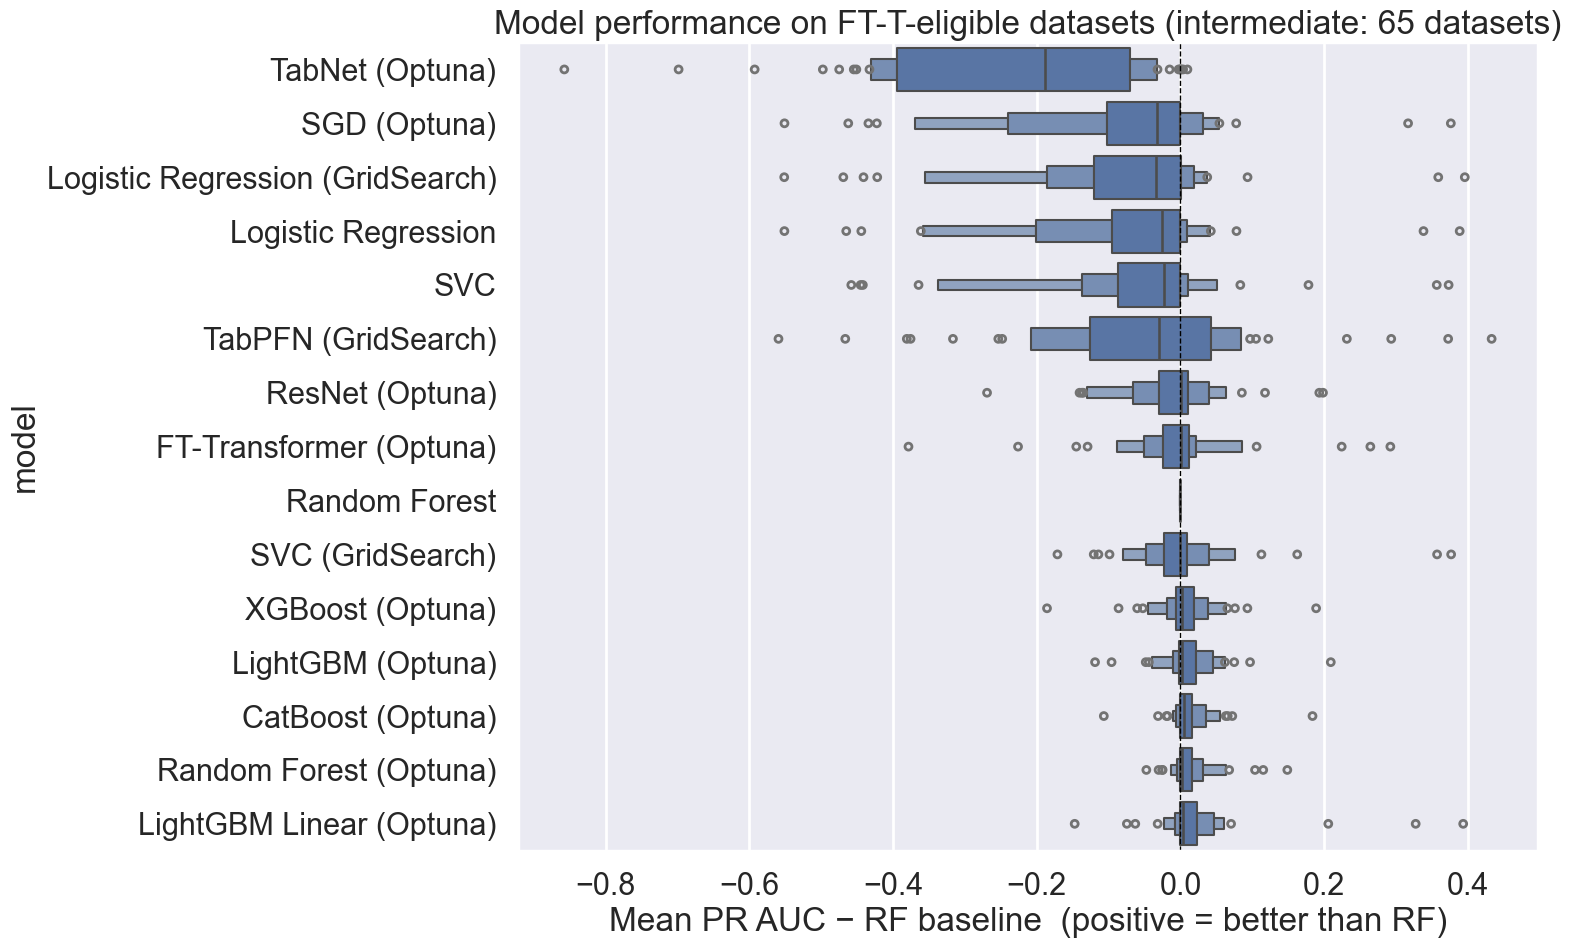

In [8]:
# Box plot: delta PR AUC vs RF baseline
plot_df = results_df[results_df['model'].isin(models_ordered)].copy()
plot_df['model'] = pd.Categorical(plot_df['model'], categories=models_ordered[::-1], ordered=True)

fig, ax = plt.subplots(figsize=(16, 10))
sns.boxenplot(data=plot_df, x='mean_delta', y='model', ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Mean PR AUC − RF baseline  (positive = better than RF)')
ax.set_title(f'Model performance on FT-T-eligible datasets (partial: {len(active_datasets)} datasets)')
plt.tight_layout()
plt.savefig('results/ft_transformer_delta_boxen.png', dpi=120)
plt.show()

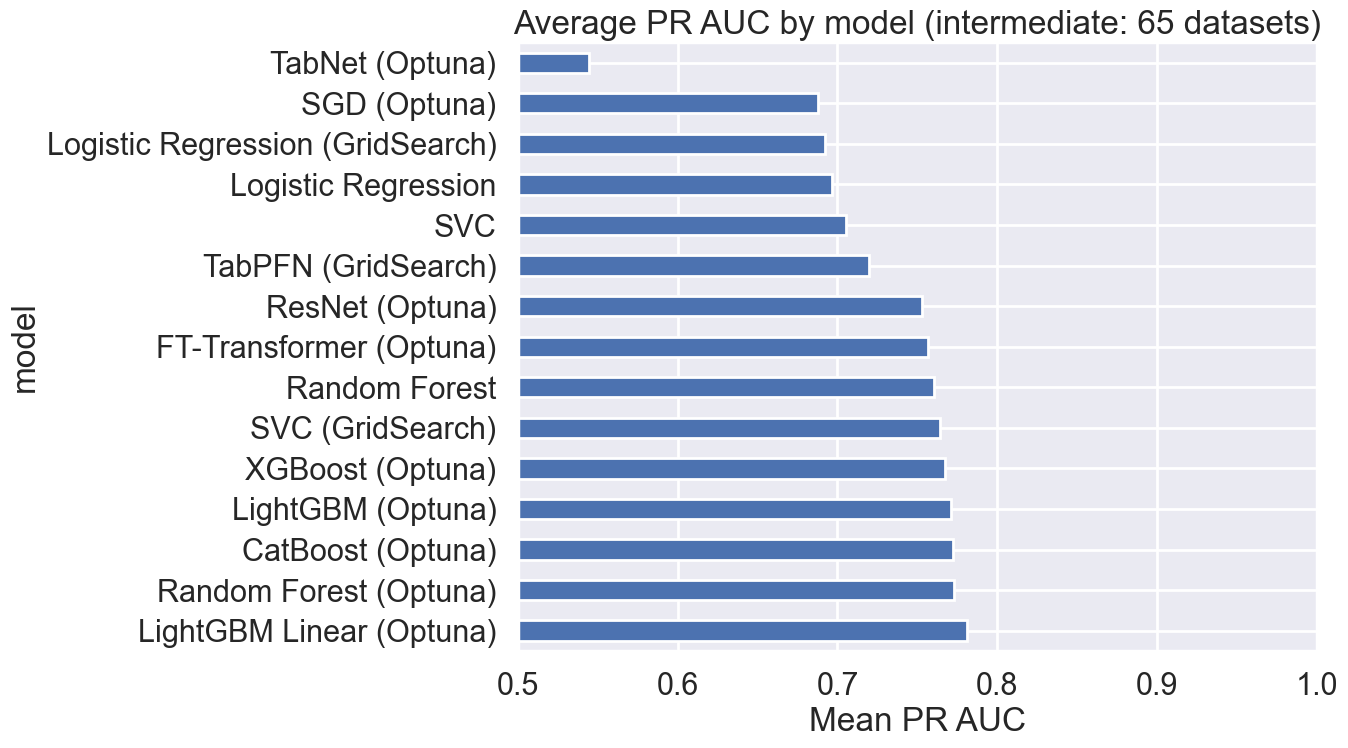

Mean PR AUC by model:
model
LightGBM Linear (Optuna)            0.780982
Random Forest (Optuna)              0.773104
CatBoost (Optuna)                   0.772258
LightGBM (Optuna)                   0.770944
XGBoost (Optuna)                    0.767033
SVC (GridSearch)                    0.764148
Random Forest                       0.760712
FT-Transformer (Optuna)             0.756928
ResNet (Optuna)                     0.752741
TabPFN (GridSearch)                 0.719729
SVC                                 0.705220
Logistic Regression                 0.696577
Logistic Regression (GridSearch)    0.692318
SGD (Optuna)                        0.687534
TabNet (Optuna)                     0.544654


In [9]:
mean_prauc_by_model = results_df.groupby('model')['mean_prauc'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
mean_prauc_by_model.plot(kind='barh', ax=ax)
ax.set_xlabel('Mean PR AUC')
ax.set_title(f'Average PR AUC by model (partial: {len(active_datasets)} datasets)')
ax.set_xlim([0.5, 1.0])
plt.tight_layout()
plt.savefig('results/ft_transformer_mean_prauc.png', dpi=120)
plt.show()

print('Mean PR AUC by model:')
print(mean_prauc_by_model.to_string())

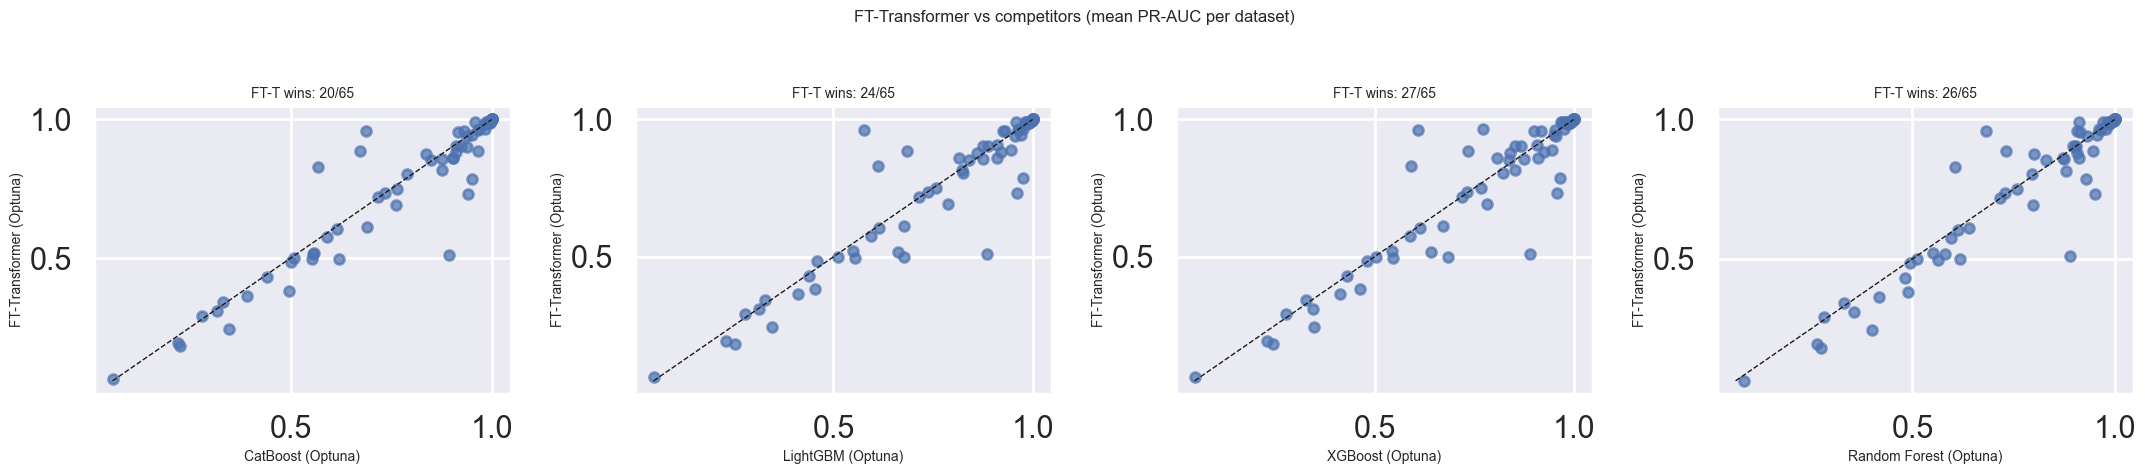

In [10]:
# FT-Transformer vs top competitors: scatter per dataset
competitors = ['CatBoost (Optuna)', 'LightGBM (Optuna)', 'XGBoost (Optuna)', 'Random Forest (Optuna)']
pivot_prauc = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')

fig, axes = plt.subplots(1, len(competitors), figsize=(22, 5), sharey=False)
for ax, comp in zip(axes, competitors):
    if comp not in pivot_prauc.columns or 'FT-Transformer (Optuna)' not in pivot_prauc.columns:
        ax.set_visible(False)
        continue
    sub = pivot_prauc[['FT-Transformer (Optuna)', comp]].dropna()
    ax.scatter(sub[comp], sub['FT-Transformer (Optuna)'], alpha=0.7, s=50)
    lims = [min(sub.min()), max(sub.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(comp, fontsize=10)
    ax.set_ylabel('FT-Transformer (Optuna)', fontsize=10)
    n_win = (sub['FT-Transformer (Optuna)'] > sub[comp]).sum()
    ax.set_title(f'FT-T wins: {n_win}/{len(sub)}', fontsize=10)

fig.suptitle('FT-Transformer vs competitors (mean PR-AUC per dataset)', fontsize=12)
plt.tight_layout()
plt.savefig('results/ft_transformer_scatter.png', dpi=120)
plt.show()

## Worth the candle? FT-Transformer cost vs gain

Compare PR-AUC delta against the **best gradient booster per dataset** (CatBoost / LightGBM / XGBoost) and look at training-time cost.

In [11]:
# Best gradient booster per dataset, then FT-T delta vs that
gb_models = ['CatBoost (Optuna)', 'LightGBM (Optuna)', 'XGBoost (Optuna)']
gb_pivot  = pivot_prauc[[m for m in gb_models if m in pivot_prauc.columns]]
best_gb   = gb_pivot.max(axis=1).rename('best_gb_prauc')
ft_series = pivot_prauc['FT-Transformer (Optuna)'].rename('ft_prauc')

cmp = pd.concat([ft_series, best_gb], axis=1).dropna()
cmp['delta'] = cmp['ft_prauc'] - cmp['best_gb_prauc']

print(f'Datasets compared: {len(cmp)}')
print(f'FT-T beats best GB:        {(cmp["delta"] > 0).sum():>3} / {len(cmp)}  ({(cmp["delta"] > 0).mean()*100:.1f}%)')
print(f'FT-T beats by >= 0.01 PRAUC: {(cmp["delta"] >= 0.01).sum():>3} / {len(cmp)}  ({(cmp["delta"] >= 0.01).mean()*100:.1f}%)')
print(f'FT-T loses by >= 0.01 PRAUC: {(cmp["delta"] <= -0.01).sum():>3} / {len(cmp)}  ({(cmp["delta"] <= -0.01).mean()*100:.1f}%)')
print()
print(f'Mean   delta vs best GB: {cmp["delta"].mean():+.4f}')
print(f'Median delta vs best GB: {cmp["delta"].median():+.4f}')
print()
print('Top 10 datasets where FT-Transformer wins:')
print(cmp.sort_values('delta', ascending=False).head(10).to_string())
print()
print('Top 10 datasets where FT-Transformer loses:')
print(cmp.sort_values('delta').head(10).to_string())

Datasets compared: 65
FT-T beats best GB:         15 / 65  (23.1%)
FT-T beats by >= 0.01 PRAUC:   9 / 65  (13.8%)
FT-T loses by >= 0.01 PRAUC:  32 / 65  (49.2%)

Mean   delta vs best GB: -0.0246
Median delta vs best GB: -0.0088

Top 10 datasets where FT-Transformer wins:
                    ft_prauc  best_gb_prauc     delta
dataset                                              
hepatitis           0.960032       0.687164  0.272869
autoUniv-au1-1000   0.829449       0.612223  0.217226
blogger             0.885243       0.733977  0.151266
leukemia-haslinger  0.956598       0.926518  0.030080
parkinsons          0.957866       0.931349  0.026518
balance-scale       0.990843       0.968889  0.021954
kr-vs-k             0.876379       0.861201  0.015178
abalone-11class     0.292324       0.279826  0.012498
abalone-7class      0.342384       0.331081  0.011303
eeg-eye-state       0.991480       0.986162  0.005318

Top 10 datasets where FT-Transformer loses:
                                  f

In [12]:
# Training-time cost: FT-T vs gradient boosters
TIME_MODELS = ['ft_transformer', 'catboost', 'lgbm', 'xgboost']
time_rows = []
for ds in active_datasets:
    if ds not in ckpt_results:
        continue
    for key in TIME_MODELS:
        if key in ckpt_results[ds]:
            time_rows.append({'dataset': ds, 'model': key, 'time_s': ckpt_results[ds][key]['time']})
times_df = pd.DataFrame(time_rows)

summary = times_df.groupby('model')['time_s'].agg(['count', 'median', 'mean', 'sum']).round(1)
summary['hours_total'] = (summary['sum'] / 3600).round(2)
print('Training time per (dataset, model):')
print(summary.to_string())
print()

wide = times_df.pivot(index='dataset', columns='model', values='time_s')
for gb in ['catboost', 'lgbm', 'xgboost']:
    if gb in wide.columns:
        ratio = (wide['ft_transformer'] / wide[gb]).dropna()
        print(f'FT-T is {ratio.median():.0f}x slower than {gb} (median),  {ratio.mean():.0f}x mean')

Training time per (dataset, model):
                count  median    mean       sum  hours_total
model                                                       
catboost           65   174.0  1069.5   69516.6        19.31
ft_transformer     65  3066.5  8144.8  529410.8       147.06
lgbm               65    46.1   110.1    7153.4         1.99
xgboost            65    25.6    60.0    3898.0         1.08

FT-T is 15x slower than catboost (median),  48x mean
FT-T is 101x slower than lgbm (median),  145x mean
FT-T is 100x slower than xgboost (median),  185x mean


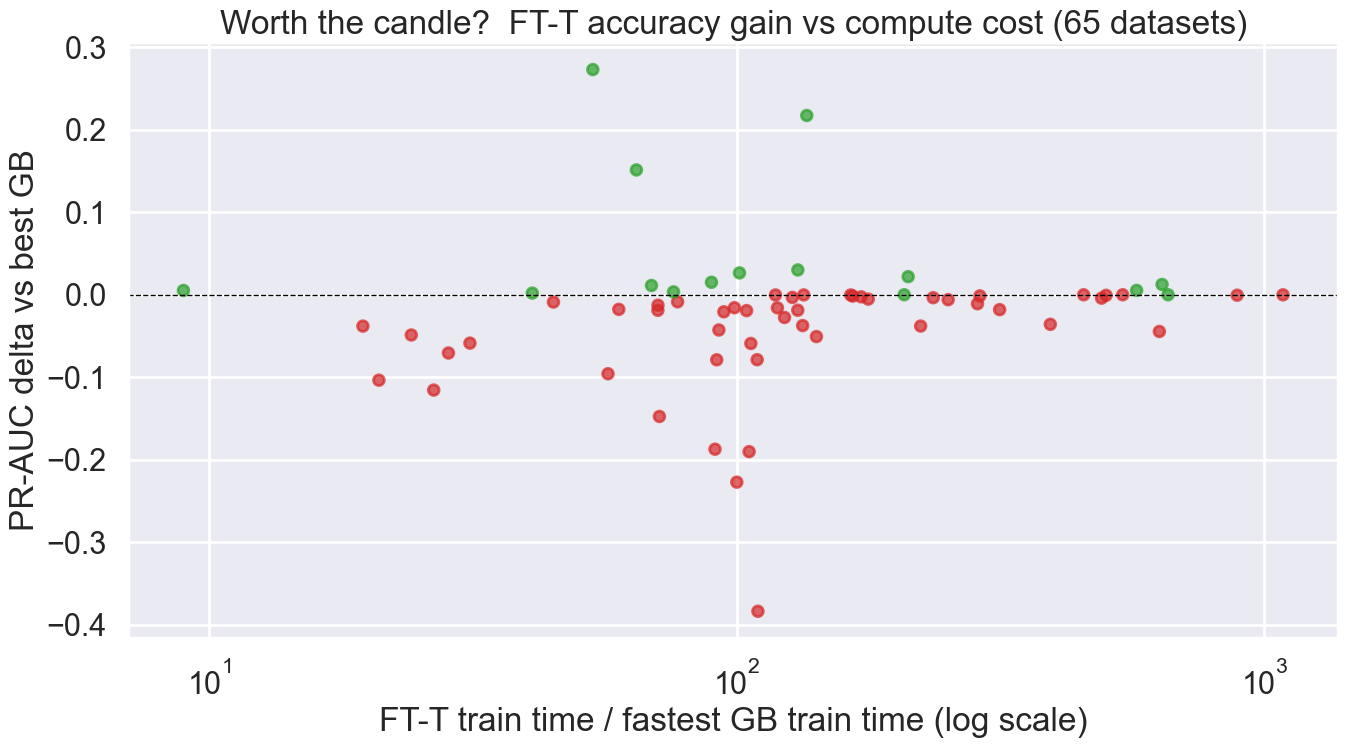


Summary:
  FT-T wins:  15 / 65 datasets
  Mean delta vs best GB: -0.0246
  Median time cost: 118x slower than best GB


In [13]:
# Verdict plot: delta vs best GB on Y, time ratio on X
verdict = cmp.join(wide[['ft_transformer'] + [m for m in ['catboost','lgbm','xgboost'] if m in wide.columns]], how='inner')
gb_time_cols = [m for m in ['catboost', 'lgbm', 'xgboost'] if m in verdict.columns]
verdict['best_gb_time'] = verdict[gb_time_cols].min(axis=1)
verdict['time_ratio']   = verdict['ft_transformer'] / verdict['best_gb_time']
verdict = verdict.dropna(subset=['delta', 'time_ratio'])

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['tab:green' if d > 0 else 'tab:red' for d in verdict['delta']]
ax.scatter(verdict['time_ratio'], verdict['delta'], c=colors, alpha=0.7, s=60)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('FT-T train time / fastest GB train time (log scale)')
ax.set_ylabel('PR-AUC delta vs best GB')
ax.set_title(f'Worth the candle?  FT-T accuracy gain vs compute cost ({len(verdict)} datasets)')
plt.tight_layout()
plt.savefig('results/ft_transformer_cost_vs_gain.png', dpi=120)
plt.show()

print()
print('Summary:')
print(f'  FT-T wins:  {(verdict["delta"] > 0).sum()} / {len(verdict)} datasets')
print(f'  Mean delta vs best GB: {verdict["delta"].mean():+.4f}')
print(f'  Median time cost: {verdict["time_ratio"].median():.0f}x slower than best GB')